# 18. The `RhoOmegaMixing` lineshape

**Objectives:** evaluate the standalone coherent rho-omega mixing shape for both
`component="rho"` and `component="omega"`, reproduce its formula by hand, combine
the two effective shapes into a one-resonance-pair `DecayModel`, and check a fit of
the Cartesian coefficients converges.

Run cells top to bottom in a fresh kernel. Masses are in GeV, invariants in GeV²,
daughter indices start at zero. `RhoOmegaMixing` reproduces Eq. (15) of the LHCb
isobar paper it is ported from: the full mixed amplitude
`Rrho * (1 + Romega * Delta * zeta) / (1 - Delta**2 * Rrho * Romega)` is split, for
fit-fraction bookkeeping, into two effective shapes -- `Rrho / denominator` for
`component="rho"` and `Delta * Rrho * Romega / denominator` for `component="omega"`
-- that a published Cartesian coefficient multiplies separately.

In [1]:
from dalitzplotfitter import enable_x64
enable_x64()

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from dalitzplotfitter import (
    DecayChannel, DecayModel, GounarisSakurai, NonResonant, Parameter, RealImag,
    Resonance, ResonanceContext, RhoOmegaMixing, FitSession, generate_toy,
)

## 1. Standalone: rho and omega effective shapes

The omega is a narrow (~8.5 MeV) spike riding on the broad rho tail near 0.78 GeV.
The `context` passed in only needs the correct pion daughter masses -- `RhoOmegaMixing`
overrides `pole_mass`/`pole_width`/`spin` internally with its own `rho_mass`,
`rho_width` fields before calling `GounarisSakurai`.

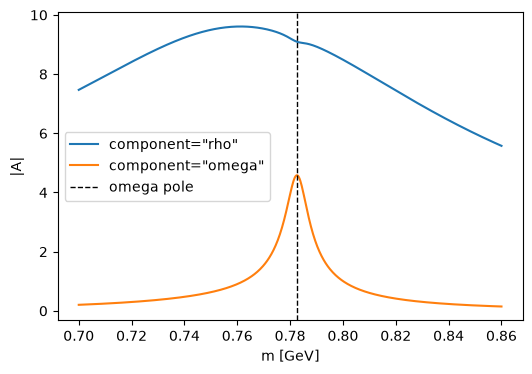

In [2]:
mpi = 0.13957
context = ResonanceContext(
    parent_mass=1.869, daughter_masses=(mpi, mpi), bachelor_mass=mpi,
    spin=1, pole_mass=0.775, pole_width=0.150,
)
mass_scan = jnp.linspace(0.70, 0.86, 600)
rho_shape = RhoOmegaMixing(component="rho")(mass_scan, context)
omega_shape = RhoOmegaMixing(component="omega")(mass_scan, context)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(mass_scan, jnp.abs(rho_shape), label='component="rho"')
ax.plot(mass_scan, jnp.abs(omega_shape), label='component="omega"')
ax.axvline(0.78265, color="black", linestyle="--", linewidth=1, label="omega pole")
ax.set(xlabel="m [GeV]", ylabel="|A|")
ax.legend()
plt.show()

## 2. Reproduce the two-piece formula by hand

Recompute `rho`, `omega`, `delta` and the shared `denominator` exactly as the
docstring/source describe, and check both class outputs against the hand-rolled
version.

In [3]:
rho_context = ResonanceContext(**{**context.__dict__, "spin": 1,
                                    "pole_mass": 0.77526, "pole_width": 0.1491})
rho = GounarisSakurai()(mass_scan, rho_context)
omega_mass, omega_width = 0.78265, 0.00849
omega = 1.0 / (omega_mass**2 - mass_scan**2 - 1j * omega_mass * omega_width)
delta = 0.00215 * (0.77526 + omega_mass)
denominator = 1.0 - delta**2 * rho * omega

np.testing.assert_allclose(rho_shape, rho / denominator, atol=1e-10)
np.testing.assert_allclose(omega_shape, delta * rho * omega / denominator, atol=1e-10)
print("Both effective shapes match the hand-rolled Eq. (15) decomposition.")

Both effective shapes match the hand-rolled Eq. (15) decomposition.


## 3. A one-resonance-pair Dalitz model

The two effective shapes enter as two separate `Resonance` components on the same
`(0, 1)` pair, each carrying its own published Cartesian coefficient, both spin 1
(the P-wave `rho`/`omega` quantum numbers).

In [4]:
channel = DecayChannel("D+", ("pi-", "pi+", "pi+"))
def coeff(name, x0, y0):
    return RealImag(
        Parameter.coefficient(f"{name}.x", x0, owner=name, bounds=(-3.0, 3.0)),
        Parameter.coefficient(f"{name}.y", y0, owner=name, bounds=(-3.0, 3.0)),
    )
model = DecayModel(
    channel,
    components=[
        Resonance("rho", (0, 1), coeff("rho", 1.0, 0.0),
                  lineshape=RhoOmegaMixing(component="rho"),
                  mass=0.77526, width=0.1491, spin=1, normalize_component=False),
        Resonance("omega", (0, 1), coeff("omega", 0.9, 0.4),
                  lineshape=RhoOmegaMixing(component="omega"),
                  mass=0.78265, width=0.00849, spin=1, normalize_component=False),
        NonResonant(coeff("NR", 0.30, -0.15), name="NR"),
    ],
    normalization_method="square-dalitz", normalization_pair=(0, 1),
    normalization_resolution=60,
)
truth = {p.name: p.value for p in model.parameters}
print("Parameters:", list(truth))

Parameters: ['rho.x', 'rho.y', 'omega.x', 'omega.y', 'NR.x', 'NR.y']


## 4. Generate a toy and fit the Cartesian coefficients

`RhoOmegaMixing`'s own mass/width/mixing parameters are literal dataclass fields, not
context-derived `Parameter` slots, so this lineshape is not meant to float its own
physics constants through the usual `owner=` mechanism; what is fittable here are the
two components' complex coefficients, exactly as for any other resonance.

In [5]:
data = generate_toy(
    model, 1500, parameters=truth, seed=18,
    method="inverse-transform", inverse_resolution=256, include_momenta=False,
)
print(f"Generated {data.size} events")

session = FitSession(model, data)
start = {"rho.x": 1.0, "rho.y": 0.0, "omega.x": 0.7, "omega.y": 0.6, "NR.x": 0.2, "NR.y": -0.05}
result = session.fit(start, simplex=True, ncall=5000)
session.report(result)
assert result.valid, "Inspect the fit diagnostics before trusting this result."


INFO DalitzPlotFitter normalization: narrow resonance band(s) detected (m12: m0=0.782650 GeV, Gamma=8.490 MeV; m13: m0=0.782650 GeV, Gamma=8.490 MeV); applying adaptive Square-Dalitz refinement only along the mass axis m'. Grid: 424 m' nodes x 60 theta' nodes (25,440 points; base 3,600).
INFO DalitzPlotFitter normalization: crossed narrow band(s) are kept on the standard theta' resolution; only resonances aligned with normalization_pair refine m'.


Generated 1500 events


valid=True  NLL=1321.705805
parameter                           value            error
rho.x                             0.94125          2.28252
rho.y                            0.486139          2.42941
omega.x                          0.598542          1.95727
omega.y                          0.659165          2.18832
NR.x                             0.294901         0.821571
NR.y                           -0.0633285         0.746092


Fit fractions (physical)
component                    fraction [%]
rho                               100.108
omega                               0.883
NR                                  0.208
sum                               101.199


## 5. Sanity check

In [6]:
fit_nll = float(session.objective({n: float(result.values[n]) for n in result.parameters}))
truth_nll = float(session.objective(truth))
print(f"NLL(fit)={fit_nll:.4f}, NLL(truth)={truth_nll:.4f}")
assert fit_nll <= truth_nll + 1e-4
print("Fit with two RhoOmegaMixing components converges to an NLL at or below truth.")

NLL(fit)=1321.7058, NLL(truth)=1322.3660
Fit with two RhoOmegaMixing components converges to an NLL at or below truth.


## Continue learning

`RhoOmegaMixing` builds on [`GounarisSakurai`](tutorial_17_gounaris_sakurai.ipynb).
See [dynamics structure](../../docs/dynamics_structure.md) and
[fit fractions](../../docs/fitting.md).

Return to [the course guide](TUTORIALS.md).